Notebook to calculate total cases, peak height, peak week, and $R_0$ for each model's predictions.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import mosqlient as mosq
from epiweeks import Week
from aux_func import get_data
from analysis import * 
import matplotlib.pyplot as plt 
import seaborn as sns 
from mosqlient.prediction_optimize import get_df_pars_ls

In [2]:
code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

state_to_code = {value: key for key, value in code_to_state.items()}

geo_dengue = [2931350,2933307,2302503,3119401,
              3549805,3541406,1200401,1200203,
              1716109,4113700,4103701,4104808,
              5201405,5102637,5215231]

geo_chik = [2211001,2931350,3143302,3119401,
            1721000,1716109,4104808,4219507,
            5103403,5102637] 

In [3]:
df_dengue_state  = get_data('dengue_state')
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)

In [4]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [5]:
df_dengue_state = df_dengue_state.merge(
        df_preds[["date", "adm_1", "validation"]].drop_duplicates(
                subset=["date", "adm_1", "validation"],
                keep="first"
            ), on=["date", "adm_1"]
    )

df_dengue_state.head()

,date,adm_1,casos,validation
0,2022-10-09,11,99,1
1,2022-10-09,12,31,1
2,2022-10-09,13,250,1
3,2022-10-09,14,2,1
4,2022-10-09,15,60,1


In [13]:
def process_single_combination(df_preds, df_dengue_state, state, model, validation, n_paths=1000, n_samples=100, seed=0):
    """
    Processa a simulação e métricas para uma única combinação de modelo e validação.
    """
    rng = np.random.default_rng(seed)
    
    # 1. Filtragem e preparação de parâmetros
    df_preds_m = df_preds.loc[(df_preds.model == model) & (df_preds.adm_1 == state)]
    #print(df_preds_m.shape)
    if df_preds_m.empty:
        return None  # Retorna None se não houver dados para essa combinação
        
    df_pars = get_df_pars_ls(df_preds_m)
    df_pars.loc[df_pars.sigma <= 0, 'sigma'] = 0.1

    # 2. Estimativa de Rho e Marginais
    df_rho_input = df_pars.loc[(df_pars['validation'] == validation - 1)].merge(
        df_dengue_state, on=['date', 'adm_1', 'validation'], how='left'
    )
    rho = estimate_rho(df_rho_input)
    marginals_uf = build_marginals(df_pars, state, validation)

    # 3. Geração das trajetórias (paths)
    paths = np.vstack([
        sample_path(marginals_uf, rho, random_state=rng)
        for _ in range(n_paths)
    ])

    # 4. Cálculo das métricas baseadas em todas as trajetórias
    season_total = paths.sum(axis=1)
    season_peak = paths.max(axis=1)

    # 5. Amostragem para ajuste da curva de Richards
    indices_aleatorios = rng.choice(paths.shape[0], size=n_samples, replace=False)
    amostras_paths = paths[indices_aleatorios, :]

    r0_dist = []
    pico_dist = []
    t_ini_dist = []
    max_c_dist = []
    richards_curves = []

    for i, path in enumerate(amostras_paths):
        r0_i, pico_i, t_ini_i, max_c_i, richards = otim_single_path(path)
        r0_dist.append(r0_i)
        pico_dist.append(pico_i)
        t_ini_dist.append(t_ini_i)
        max_c_dist.append(max_c_i)

        df_curve = pd.DataFrame({
            "sample": i,
            "week": np.arange(len(richards)),
            "richards": richards
        })

        richards_curves.append(df_curve)

    richards_df = pd.concat(richards_curves, ignore_index=True)

    r0_dist = np.array(r0_dist)
    pico_dist = np.array(pico_dist)
    t_ini_dist = np.array(t_ini_dist)
    max_c_dist = np.array(max_c_dist)

    # 6. Consolidação dos resultados em um dicionário de intervalos
    metrics = {
        'model': model,
        'validation': validation,
        'state': state
    }
    
    # Dicionário mapeando o nome da métrica para o seu array de distribuição
    distributions = {
        'season_total': season_total,
        'season_peak': season_peak,
        'r0_dist': r0_dist,
        'pico_dist': pico_dist, 
        't_ini_dist': t_ini_dist, 
        'max_c_dist': max_c_dist
    }
    
    # Calcula os quantis automaticamente para cada métrica
    for name, dist in distributions.items():
        lo, med, hi = np.quantile(dist, [0.025, 0.5, 0.975])
        metrics[f'{name}_p25'] = lo
        metrics[f'{name}_p50'] = med
        metrics[f'{name}_p975'] = hi


    # Salva os resultados: 
    table_suffix = f"{state}_{model}_{validation}_{challenge}".replace("-", "_")

    df_pars.to_csv(f'./samples/pars_{table_suffix}.csv.gz', index = False)

    df_paths = (
        pd.DataFrame(paths)
        .reset_index(names="path")
        .melt(
            id_vars="path",
            var_name="week",
            value_name="cases"
        )
    )

    df_paths.to_csv(
        f"./samples/paths_{table_suffix}.csv.gz",
        index=False
    )

    # curvas de Richards
    richards_df.to_csv(
        f"./samples/richards_{table_suffix}.csv.gz",
        index=False
    )

    return metrics

In [7]:
def run_pipeline(df_preds, df_dengue_state, state, models_list, validations_list):
    """
    Executa o loop por todos os modelos e validações e retorna um DataFrame consolidado.
    """
    results = []
    
    for model in models_list:
        for validation in validations_list:
            #print(f"Processando: Modelo={model} | Validation={validation}...")
            try:
                res = process_single_combination(df_preds, df_dengue_state, state, model, validation)
                if res is not None:
                    results.append(res)
            except Exception as e:
                print(f"Erro ao processar Modelo={model}, Validation={validation}: {e}, State: {state}")
                continue
                
    # Transforma a lista de dicionários em um DataFrame estruturado
    df_results = pd.DataFrame(results)
    return df_results

In [8]:
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [10]:
model = '3rd_imdc_isi_isi-dengue'
validation = 4 
state = 50 

df_ = df_preds.loc[(df_preds.model == model) & (df_preds.adm_1 == state) & (df_preds.validation == validation)]

df_.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
2505,2025-10-05,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,50,7618,4,207.05,3rd_imdc_isi_isi-dengue
2506,2025-10-12,173.203260,176.884328,180.603714,187.438199,195.147765,203.032071,210.028494,214.638745,218.635144,50,7618,4,207.05,3rd_imdc_isi_isi-dengue
2507,2025-10-19,158.147180,163.231070,168.987494,178.892865,190.999561,203.184331,214.314592,221.726151,227.577649,50,7618,4,207.05,3rd_imdc_isi_isi-dengue
2508,2025-10-26,158.538794,163.379081,168.842223,178.388614,189.726809,201.325986,211.877857,218.710647,224.199088,50,7618,4,207.05,3rd_imdc_isi_isi-dengue
2509,2025-11-02,161.860872,166.347090,171.415434,180.306079,190.707227,201.443775,211.067477,217.211339,222.269216,50,7618,4,207.05,3rd_imdc_isi_isi-dengue


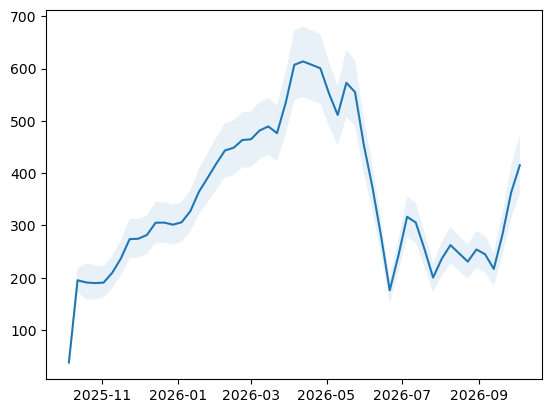

In [11]:
_,ax = plt.subplots()

ax.plot(df_.date, df_.pred)
ax.fill_between(df_.date, df_.lower_95, df_.upper_95, alpha = 0.1)

In [12]:
df_pars = get_df_pars_ls(df_)
df_pars.loc[df_pars.sigma == 0, 'sigma'] = 0.1

df_pars.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model,mu,sigma
2505,2025-10-05,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,50,7618,4,207.05,3rd_imdc_isi_isi-dengue,3.637586,-1.140722e-32
2506,2025-10-12,173.203260,176.884328,180.603714,187.438199,195.147765,203.032071,210.028494,214.638745,218.635144,50,7618,4,207.05,3rd_imdc_isi_isi-dengue,5.272271,5.911988e-02
2507,2025-10-19,158.147180,163.231070,168.987494,178.892865,190.999561,203.184331,214.314592,221.726151,227.577649,50,7618,4,207.05,3rd_imdc_isi_isi-dengue,5.248674,9.298262e-02
2508,2025-10-26,158.538794,163.379081,168.842223,178.388614,189.726809,201.325986,211.877857,218.710647,224.199088,50,7618,4,207.05,3rd_imdc_isi_isi-dengue,5.242423,8.858533e-02
2509,2025-11-02,161.860872,166.347090,171.415434,180.306079,190.707227,201.443775,211.067477,217.211339,222.269216,50,7618,4,207.05,3rd_imdc_isi_isi-dengue,5.248083,8.108741e-02


In [ ]:
%%time
# Listas de modelos e validações que você quer rodar
lista_modelos = df_preds.model.unique()
lista_validations = [2,3,4]

states = df_preds.adm_1.unique()


df_all_adm = pd.DataFrame()

for state_alvo in states: 

    # Executa o pipeline
    df_final_resultados = run_pipeline(df_preds, df_dengue_state, state_alvo, lista_modelos, lista_validations)

    # Salva os resultados em um arquivo
    df_all_adm = pd.concat([df_all_adm, df_final_resultados], ignore_index=True) 


df_all_adm.head()

In [21]:
df_all_adm.to_csv(f'predictions/new_metrics_{challenge}.csv.gz', index = False)

### Get the True parameters:

In [22]:
df_ = df_dengue_state.merge(df_preds[['date', 'validation']].drop_duplicates(), on = ['date', 'validation'] , how = 'left').dropna()

df_.head()

,date,adm_1,casos,validation
0,2022-10-09,11,99,1
1,2022-10-09,12,31,1
2,2022-10-09,13,250,1
3,2022-10-09,14,2,1
4,2022-10-09,15,60,1


In [23]:
from itertools import product
state = 11 
validation = 1 

list_pars = []

for state, validation in product(df_.adm_1.unique(), df_.validation.unique()):  
    df_state = df_.loc[(df_.adm_1 == state) & (df_.validation == validation)].sort_values(by = 'date')

    r0_i, pico_i, t_ini_i, max_c_i, richards = otim_single_path(df_state.casos.values)
    total_cases = df_state.casos.sum()
    max_cases = df_state.casos.max()


    df_curve = pd.DataFrame({
                "week": np.arange(len(richards)),
                "richards": richards
            })

    df_curve.to_csv(
        f"./samples/richards_true_data_{state}.csv.gz",
        index=False
    )

    list_pars.append(pd.DataFrame([[state, validation, pico_i, total_cases, max_cases,
                                    max_c_i, t_ini_i]], columns = ['state', 'validation', 
                                                                                                    'peak_week', 'total_cases', 'peak_height', 'peak_height_model', 't_ini']))

df_params = pd.concat(list_pars)

df_params.head()

,state,validation,peak_week,total_cases,peak_height,peak_height_model,t_ini
0,11,1,17.912460,13281,864,750.147209,1
0,11,2,20.624851,5583,604,424.351398,6
0,11,3,28.967172,2553,142,113.486196,1
0,11,4,23.444633,1472,72,64.545081,1
0,12,1,22.992623,4735,288,236.612882,1


<Axes: >

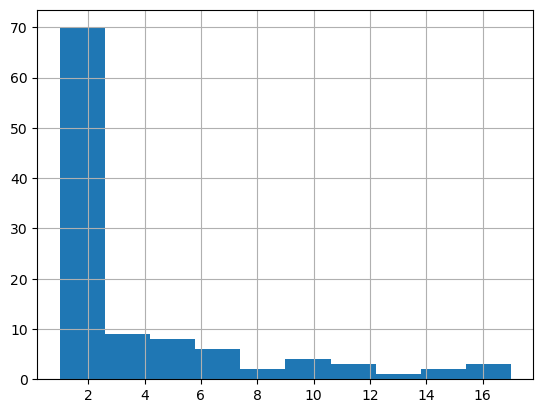

In [19]:
df_params.t_ini.hist()

In [22]:
df_params.loc[df_params.state == 22]

,state,validation,peak_week,total_cases,peak_height,peak_height_model,t_ini
0,22,1,27.994471,7562,436,411.562657,6
0,22,2,27.143179,14854,848,854.639472,7
0,22,3,29.669147,9079,459,405.412446,2
0,22,4,29.305335,13465,1009,921.760006,8


In [24]:
df_params.to_csv('data/parameters_dengue_state.csv.gz', index=False)

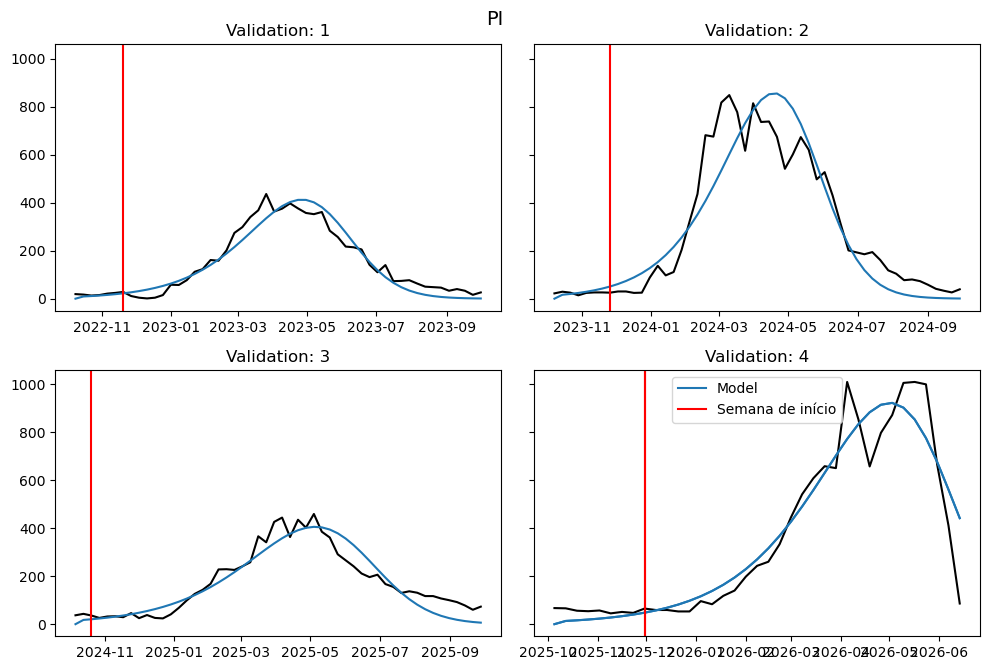

In [ ]:

_, ax = plt.subplots(2,2, figsize = (10,7), sharey=True)

state = 22
validation = 1

for ax_, validation in zip(ax.ravel(), [1,2,3,4]): 
    df_state = df_.loc[(df_.adm_1 == state) & (df_.validation == validation)].sort_values(by = 'date')

    r0_i, pico_i, t_ini_i, max_c_i, richfun_opt  = otim_single_path(df_state.casos.values)


    ax_.plot(df_state.date, df_state.casos, color = 'black')
    ax_.plot(df_state.date, diff_r)
    ax_.set_title(f'Validation: {validation}')
    ax_.axvline(df_state['date'].values[int(t_ini_i)], color = 'red')

ax_.plot(df_state.date, diff_r, color = 'tab:blue', label = 'Model')
ax_.axvline(df_state['date'].values[int(t_ini_i)], color = 'red', label = 'Semana de início')
ax_.legend()

plt.suptitle('PI', y = 0.95, fontsize =14)
plt.tight_layout()

plt.show()

In [20]:
df_state['date'].values

array(['2022-10-09T00:00:00.000000', '2022-10-16T00:00:00.000000',
       '2022-10-23T00:00:00.000000', '2022-10-30T00:00:00.000000',
       '2022-11-06T00:00:00.000000', '2022-11-13T00:00:00.000000',
       '2022-11-20T00:00:00.000000', '2022-11-27T00:00:00.000000',
       '2022-12-04T00:00:00.000000', '2022-12-11T00:00:00.000000',
       '2022-12-18T00:00:00.000000', '2022-12-25T00:00:00.000000',
       '2023-01-01T00:00:00.000000', '2023-01-08T00:00:00.000000',
       '2023-01-15T00:00:00.000000', '2023-01-22T00:00:00.000000',
       '2023-01-29T00:00:00.000000', '2023-02-05T00:00:00.000000',
       '2023-02-12T00:00:00.000000', '2023-02-19T00:00:00.000000',
       '2023-02-26T00:00:00.000000', '2023-03-05T00:00:00.000000',
       '2023-03-12T00:00:00.000000', '2023-03-19T00:00:00.000000',
       '2023-03-26T00:00:00.000000', '2023-04-02T00:00:00.000000',
       '2023-04-09T00:00:00.000000', '2023-04-16T00:00:00.000000',
       '2023-04-23T00:00:00.000000', '2023-04-30T00:00:00.0000

In [21]:
df_state['date'].values[int(t_ini_i)]

np.datetime64('2022-11-20T00:00:00.000000')

In [11]:
df_state

,date,adm_1,casos,validation
8,2022-10-09,22,19,1
35,2022-10-16,22,17,1
62,2022-10-23,22,13,1
89,2022-10-30,22,15,1
116,2022-11-06,22,21,1
143,2022-11-13,22,24,1
170,2022-11-20,22,28,1
197,2022-11-27,22,11,1
224,2022-12-04,22,4,1
251,2022-12-11,22,1,1
